Today's topics:
* vectorized predictions and residuals
* MSE and RMSE: the typical miss, in the units of the property
* $R^2$, and what it does and doesn't tell us
* the residual plot: diagnosing a fit from what it leaves behind

# One alloy, not the average

L12 closed on a caution: a fitted line describes the average alloy in a compilation, not any particular one.

Today we put a number on that caution.
The same 190-alloy compilation includes one alloy whose reported ultimate tensile strength sits below its own yield strength, a margin of -45 MPa.

No alloy can fracture at a lower stress than the one that made it yield in the first place.
For an alloy that strong the fitted line puts the margin at about +178 MPa, so this row lands more than 200 MPa away from it.

That disagreement has a name: the residual, how far one alloy actually sits from what the line predicts for it.

Same fitted line, two very different outcomes.
The alloy on the right is TiZr-5Al, and its measured margin runs the other direction entirely.

## Rebuilding the fit from L12

L12 loaded this compilation and fit a line through it.
Let's rebuild both, quickly.

> The compilation is [Salvador et al., *Scientific Data* 9, 188](https://doi.org/10.1038/s41597-022-01283-9), CC BY 4.0.

In [1]:
#@title Load the Ti-alloy dataset (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import pandas as pd


def _find(name):
    return next(
        (p for p in (f'datasets/{name}', f'../datasets/{name}', f'../../datasets/{name}',
                     f'../../../datasets/{name}')
         if os.path.exists(p)),
        f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{name}',
    )


try:
    data = pd.read_csv(_find('biomaterials_ti_alloys.csv'))
except Exception as e:
    raise RuntimeError(
        "Could not load the Ti-alloy data. If you are in Colab, check your "
        "internet connection."
    ) from e

print(f'Loaded {len(data)} titanium alloys')
data[['eid', 'YS_MPa', 'UTS_MPa']].head()

Loaded 283 titanium alloys


,eid,YS_MPa,UTS_MPa
0,Ti-23Nb-10Zr-2.0Fe,782.0,NaN
1,Ti-27Nb-10Zr-1.5Fe,735.0,NaN
2,Ti-31Nb-10Zr-1.0Fe,672.0,NaN
3,Ti-11Nb-7Zr-3.5Fe,1011.0,NaN
4,Ti-19Nb-6Sn-2.5Fe,765.0,NaN


In [2]:
import numpy as np
from scipy import stats

both = data.dropna(subset=['YS_MPa', 'UTS_MPa'])  # 283 rows down to the 190 reporting both
x = both['YS_MPa']
y = both['UTS_MPa']

result = stats.linregress(x, y)
print(f'{len(both)} alloys, same fit as L12')
print(f'slope     = {result.slope:.4f}')
print(f'intercept = {result.intercept:.2f} MPa')
print(f'r         = {result.rvalue:.4f}')

190 alloys, same fit as L12
slope     = 0.9846
intercept = 204.27 MPa
r         = 0.8822


# Vectorized prediction

The fitted line is a function now.
Passing every yield strength to it at once predicts every tensile strength, with no loop required.

In [3]:
y_hat = result.slope * x + result.intercept  # one line, 190 predictions
print(y_hat.head())

12    546.897436
13    800.917610
14    819.624522
15    823.562820
20    732.981982
Name: YS_MPa, dtype: float64


`y_hat` is 190 predictions, one per alloy, computed in one vectorized line.

## Drawing the fitted line

Those 190 predictions are points on the fitted line, so the obvious thing to try is to plot them on top of the alloys.

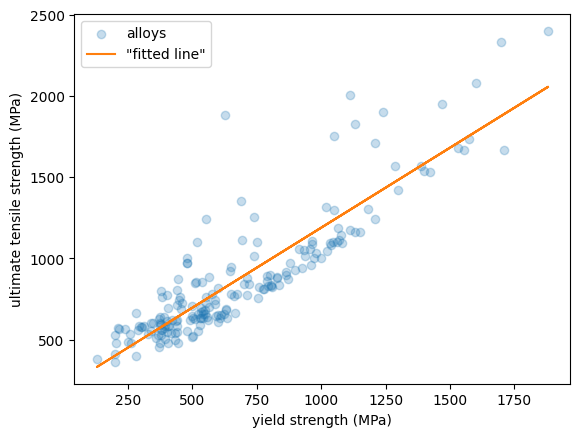

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.25, label='alloys')
ax.plot(x, y_hat, color='tab:orange', label='"fitted line"')
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')
ax.legend()

Every one of those predicted points sits on the straight line, and the picture is a scribble.

`ax.plot` draws a segment from each point to the next one in the order they are stored, and `x` is in whatever order the compilation happened to list the alloys.
So the line is drawn to a high yield strength, back to a low one, forward again: across its 189 segments the direction reverses 80 times, retracing the same fitted line.

## Two x values instead of the whole column

A straight line needs exactly two points, so take the smallest and largest yield strength and put those through the equation.
The smallest and largest are guaranteed to be in order, which is the whole of the problem above.

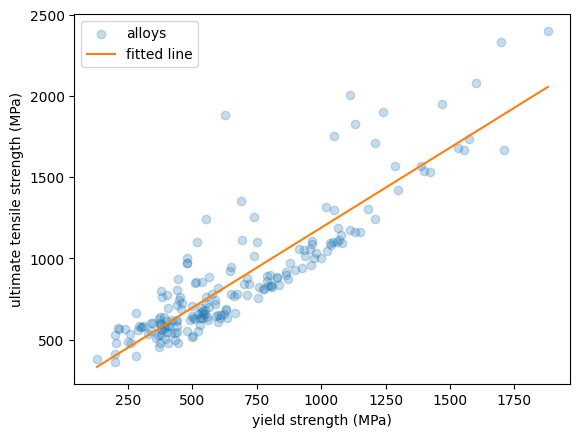

In [5]:
xx = np.array([np.min(x), np.max(x)])
yy = result.slope * xx + result.intercept

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.25, label='alloys')
ax.plot(xx, yy, color='tab:orange', label='fitted line')
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')
ax.legend()

## Residuals

The residual is the gap between what actually happened and what the line predicted: `residual = y - y_hat`.

In [6]:
residuals = y - y_hat  # measured minus predicted, so negative means the line was too optimistic
print(residuals.head())
print(f'sum of residuals: {np.sum(residuals):.6f}')  # zero, up to rounding

12     54.102564
13   -167.917610
14   -163.624522
15   -134.562820
20    119.018018
dtype: float64
sum of residuals: 0.000000


That sum lands on zero, up to rounding.
For a least-squares fit evaluated on the data it was fit to, this is always true.

A fit graded by summing its own residuals would always produce zero, so summing is not the useful question.
Spread is.

## The shape of the misses

A histogram shows all 190 residuals at once, before any single number stands in for them.

Text(0, 0.5, 'number of alloys')

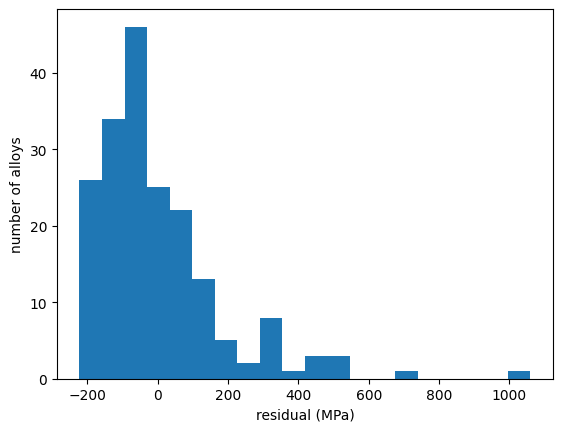

In [7]:
fig, ax = plt.subplots()
ax.hist(residuals, bins=20)
ax.set_xlabel('residual (MPa)')
ax.set_ylabel('number of alloys')

Most alloys sit within a couple of hundred MPa of the line, on both sides of zero, and a few miss it by far more.
That is the spread the sum threw away.

## MSE and RMSE

Squaring each residual before averaging is what stops the signs cancelling.
The average of the squares is the mean squared error.

In [8]:
mse = np.mean(residuals ** 2)
print(f'MSE  = {mse:.0f} MPa^2')
print(f'RMSE = {np.sqrt(mse):.1f} MPa')

MSE  = 32797 MPa^2
RMSE = 181.1 MPa


The MSE is in MPa squared, which is not a unit anyone can picture.
Taking the square root undoes that and puts the answer back in MPa: the root mean squared error, 181.1 MPa.

An individual alloy typically misses the line's prediction by about that much, in either direction, even though this is the best straight line available for this data.

# $R^2$

RMSE is in MPa, tied to this one property pair.
$R^2$ reports fit quality on a scale that works for any pair, by asking what the line beats.

The thing it has to beat is the laziest model there is: ignore yield strength entirely and predict the mean tensile strength every time.
That model has residuals too, and they are just how far each alloy sits from the mean.

In [9]:
mean_residuals = y - np.mean(y)  # what the lazy model gets wrong

r_squared = 1 - np.var(residuals) / np.var(mean_residuals)
print(f'R² = {r_squared:.4f}')
print(f"result.rvalue ** 2 = {result.rvalue ** 2:.4f}")  # the same number, straight off the fit

R² = 0.7782
result.rvalue ** 2 = 0.7782


0.78 either way.
Computing it from the residuals directly and reading it off `result.rvalue` are the same calculation, arrived at two ways.

An $R^2$ of 0 would mean the line does no better than always predicting the mean, and 1 would mean it misses nothing.

> Subtracting the mean shifts a column without spreading it, so `np.var(mean_residuals)` is the same number as `np.var(y)`.
> Writing it the long way is what puts the rival model on the page instead of leaving it implied.

$R^2$ is a spectrum, not a pass/fail line.
0.78 means the fit accounts for 78% of why tensile strength varies from alloy to alloy in this compilation.
The other 22% is real scatter the line does not explain: composition, processing route, and microstructure absent from the two-column fit.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cd/CrystalGrain.jpg/960px-CrystalGrain.jpg" alt="Optical micrograph of a quenched titanium alloy, showing irregular crystal grains of varying size and orientation meeting at boundaries" width=520/>

Microstructure of the titanium alloy VT22 after quenching.
Photo by Edward Pleshakov, [CC BY 3.0](https://creativecommons.org/licenses/by/3.0/), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:CrystalGrain.jpg).

Two alloys can have the same reported yield strength and look nothing like one another under a microscope.
The fit uses only two columns of numbers, with none of that microstructural information included.

### [Check your understanding]

`Mo_equivalent` is an engineered descriptor of how strongly an alloy favors the body-centered-cubic beta phase, computed from this table's own composition columns rather than measured on a testing machine.
Put it through the same call and decide what the line is worth.

1. Build `has_mo`, the rows with both `Mo_equivalent` and `YS_MPa`, using `.dropna(subset=[...])`.
2. Fit `stats.linregress` with `Mo_equivalent` as x and `YS_MPa` as y, and print how many alloys went into it.
3. Compute that fit's residuals, and its $R^2$ from the mean baseline the way we did above.
4. Print `result_mo.rvalue ** 2` as well and check the two agree.
5. In a comment, say how that $R^2$ compares with the 0.78 we got for tensile strength, and whether the line is beating the mean by much.

*Optional challenge:* draw the residual plot for this fit too, and say whether it looks like the one above.

*Composition sets the phase an alloy favors, while grain size, processing route and heat treatment are nowhere in `Mo_equivalent`. What does the $R^2$ you computed support saying about predicting yield strength from beta stability alone?*

# The residual plot

$R^2$ is one number for all 190 residuals.
Plotting them against the predictor turns those 190 numbers into a picture.

Text(0, 0.5, 'residual (MPa)')

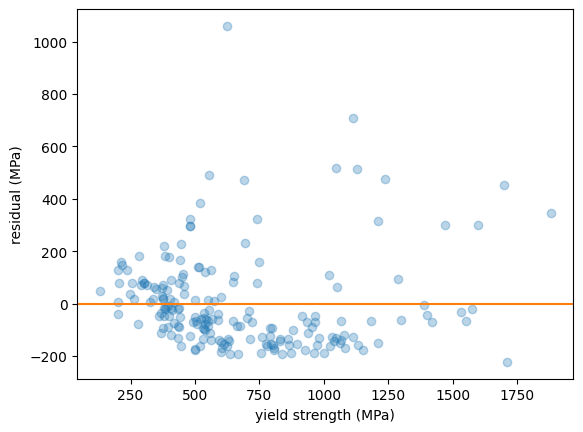

In [10]:
fig, ax = plt.subplots()
ax.scatter(x, residuals, alpha=0.3)  # alpha makes the overlapping points readable
ax.axhline(0, color='tab:orange')  # the line itself, now flat: a perfect prediction sits here
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('residual (MPa)')

A residual plot with no visible pattern, points scattered above and below zero across the whole range of yield strength, is what a good linear fit looks like.
It says the line has already captured whatever depends linearly on yield strength, and what is left over is unstructured scatter.

A residual plot with a visible curve or trend says the opposite: the line is missing something systematic, not just noise.

## Finding the extreme row with a mask

One point in that scatter sits well below the rest, near the bottom of the plot.
Let's pull it out by name.

In [11]:
worst = both.loc[residuals == np.min(residuals)]  # the mask picks the single lowest point
print(worst[['eid', 'YS_MPa', 'UTS_MPa', 'YS_err', 'UTS_err']])
print(f'residual: {np.min(residuals):.0f} MPa')

         eid  YS_MPa  UTS_MPa  YS_err  UTS_err
96  TiZr-5Al  1710.0   1665.0   140.0    165.0
residual: -223 MPa


TiZr-5Al: a measured UTS of 1665 MPa against a measured YS of 1710 MPa, the -45 MPa margin from the opening sketch.
Its residual, -223 MPa, is the single most negative of all 190, which is why it appears at the bottom of the plot.

Its `YS_err` and `UTS_err` are the two largest reported for any alloy kept in this fit.

In [12]:
print(f"largest YS_err in the fit:  {np.max(both['YS_err']):.0f} MPa")
print(f"largest UTS_err in the fit: {np.max(both['UTS_err']):.0f} MPa")

largest YS_err in the fit:  140 MPa
largest UTS_err in the fit: 165 MPa


140 MPa and 165 MPa, both belonging to this same row.
Combined, that reported uncertainty is more than six times the 45 MPa gap between the two measured values.

This alloy is not obviously mismeasured.
It is the single least certain measurement pair in the whole compilation, with error bars wide enough on their own to make an impossible-looking pair of numbers plausible.

## What that `np.max` leaves out

Only 81 of these 190 alloys report a `YS_err` at all.
L08 told us that `np.max` over an array holding a `NaN` returns `NaN`, and that is still true.

In [13]:
reported = both.dropna(subset=['YS_err'])  # the rows that give an uncertainty at all
print(f'alloys reporting YS_err: {len(reported)} of {len(both)}')
print(f"np.max on the Series: {np.max(both['YS_err'])}")
print(f"np.max on the same numbers as an array: {np.max(both['YS_err'].to_numpy())}")

alloys reporting YS_err: 81 of 190
np.max on the Series: 140.0
np.max on the same numbers as an array: nan


A `Series` skips its missing values on the way through; the array does not.
So the 140 MPa above is the largest of the 81 alloys that reported an uncertainty, not of all 190.

That is worth saying out loud every time, because the number comes back either way and only one of the two spellings shows the difference.

Catching a point like this systematically, rather than by scanning a plot, is a topic for identifying outliers, still ahead after the midterm.
For now the plot itself is the diagnostic: eyeball it, and follow up on whatever sits far from the rest.

### [Check your understanding]

Run the whole diagnosis again on a different property pair: yield strength against Young's modulus.

1. Build `has_ym`, the rows with both `YM_GPa` and `YS_MPa`, using `.dropna(subset=[...])`.
2. Fit `stats.linregress` with `YS_MPa` as x and `YM_GPa` as y, and print the $R^2$.
3. Compute the residuals of that fit.
4. Scatter those residuals against `YS_MPa`, with a horizontal line at zero.
5. In a comment, say whether the scatter looks structureless or shows a pattern.

*Optional challenge:* mark the single most negative residual on the plot with a second `ax.scatter` call in a different color.

*Is modulus a tighter or a looser fit against yield strength than tensile strength was, and is that difference consistent between the residual plot and the $R^2$?*

# Correlation is not causation

L12 warned that a large `r` does not establish causation, and the same warning applies to $R^2$.

A high $R^2$ says two columns move together in this compilation.
A high $R^2$ does not establish which variable, if either, causes the other.

[Tyler Vigen's *Spurious Correlations*](https://www.tylervigen.com/spurious-correlations) collects real pairs of numbers that track each other for no reason at all.
Between 2000 and 2009, per capita mozzarella cheese consumption in the United States and the number of civil engineering doctorates awarded rose together with a correlation of $r = 0.9586$.

Square it, the way we did at the top of the lecture, and that pair has an $R^2$ of 0.919 against our 0.778.
It is the better fit of the two, and nobody thinks the cheese is making the engineers.

The same caution applies to materials data: a strong fit is worth investigating further, not worth assuming an explanation for.

# Summary

* Vectorized prediction (`y_hat = m*x + b` over a whole array) and the residual (`y - y_hat`) turn one fitted line into 190 individual comparisons at once.
* Residuals from a least-squares fit sum to about zero on the data they were fit to, so fit quality depends on their spread, not their sum.
* $R^2$, `1 - Var(residuals)/Var(mean_residuals)`, is how much of that spread the line removes compared with always predicting the mean: a spectrum from 0 to 1, not a pass/fail line.
* A residual plot turns a column of numbers into a shape. Structureless scatter about zero is a fit with nothing systematic left over; visible structure, or one extreme point, says otherwise.
* A high $R^2$ says two columns move together in this compilation, but it does not establish which one, if either, causes the other.

Across these 190 titanium alloys the line accounts for 78% of why tensile strength varies, which is a good fit, and an individual alloy still typically sits about 181 MPa off it in either direction.
The opening row is the extreme case: at its 1710 MPa yield strength the line predicts 1888 MPa and the measurement reports 1665.
An implant designer gets the population from a line like this one, and gets the hip stem from a tensile test.

## Further reading

- Salvador, C. A. F. et al. "A compilation of experimental data on the mechanical properties and microstructural features of Ti-alloys." *Scientific Data* 9, 188 (2022). https://doi.org/10.1038/s41597-022-01283-9
- [Tyler Vigen, *Spurious Correlations*](https://www.tylervigen.com/spurious-correlations)
- [SciPy documentation: `scipy.stats.linregress`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html)